# Kernel Trick in Support Vector Machines (SVM)

## The Problem: Non-Linearly Separable Data

So far, SVM assumes that the data is **linearly separable**.

This means that we can separate the classes using a straight line (2D) or a hyperplane (higher dimensions).

However, many real-world datasets look like this:

* One class surrounds another.
* Classes overlap in complex patterns.
* No straight line can separate them.

In such cases, Linear SVM fails.

---

# The Main Idea

Instead of trying to separate the data in the original space, we:

> Transform the data into a higher-dimensional space where the classes become linearly separable.

---

# Feature Mapping

Suppose our original data has two features:

$$
(x_1, x_2)
$$

We apply a transformation:

$$
\phi(x)
$$

which maps the data into a higher-dimensional space.

Example:

$$
\phi(x_1,x_2)
=
(x_1,x_2,x_1^2+x_2^2)
$$
--
Now each point has three dimensions:

$$
(x_1,x_2,z)
$$

where

$$
z = x_1^2+x_2^2
$$

---

# Why Does This Help?

Imagine points that are impossible to separate in 2D.

After adding:

$$
x_1^2+x_2^2
$$

as a third dimension:

* Some points move upward.
* Some points stay lower.

Suddenly, we can draw a flat plane that perfectly separates the classes.

In the original space, the boundary looked non-linear.

In the transformed space, it becomes linear.

---

# The Problem with Explicit Mapping

For small dimensions, mapping is easy.

But in practice:

* Hundreds of features
* Thousands of features
* Infinite-dimensional transformations

Computing all transformed coordinates becomes extremely expensive.

---

# The Kernel Trick

Instead of explicitly calculating:

$$
\phi(x)
$$

we compute only the **inner product** in the transformed space.

The kernel function is:

$$
K(x_i,x_j)
=
\langle
\phi(x_i),
\phi(x_j)
\rangle
$$
--
This gives us the same result without ever computing the higher-dimensional coordinates.

This is called:

# The Kernel Trick

---

# Why Is It Powerful?

The kernel trick allows us to:

* Work in very high dimensions.
* Save memory.
* Save computation time.
* Build highly non-linear decision boundaries.

Without explicitly creating those dimensions.

---

# Common Kernel Functions

## 1. Linear Kernel

$$
K(x,y)
=
x^Ty + c
$$
--
### When to Use?

* Data is already linearly separable.
* Large number of features.
* Fastest kernel.

---

## 2. Polynomial Kernel

$$
K(x,y)
=
(\gamma x^Ty + r)^d
$$
--
where:

* $\gamma$ → scaling factor
* $r$ → constant term
* $d$ → degree of polynomial

### Intuition

Creates polynomial feature interactions.

Useful when the relationship between features is polynomial.

---

## 3. Radial Basis Function (RBF) Kernel

$$
K(x,y)
=
\exp(-\gamma ||x-y||^2)
$$
--
### Intuition

Measures similarity between two points.

* Nearby points → Similarity close to 1
* Far points → Similarity close to 0

The RBF kernel can map data into an extremely high-dimensional (even infinite-dimensional) space.

This is the most commonly used kernel in practice.

---

## 4. Sigmoid Kernel

$$
K(x,y)
=
\tanh(\gamma x^Ty + r)
$$
--
### Intuition

Behaves similarly to a small neural network.

Historically inspired by neural networks.

---

# Choosing the Right Kernel

## Linear Kernel

Use when:

* Number of features is very large.
* Data is approximately linear.

Examples:

* Text Classification
* Spam Detection

---

## RBF Kernel

Use when:

* Number of features is small.
* Relationship is highly non-linear.

Examples:

* Image Classification
* Medical Data

---

## Polynomial Kernel

Use when:

* Feature interactions matter.
* The relationship follows polynomial patterns.

---

# Hyperparameter Tuning

Kernel performance depends heavily on hyperparameters.

Examples:

### RBF

$$
\gamma
$$

### Polynomial

$$
d
$$

Usually tuned using:

* Grid Search
* Random Search
* Cross Validation

---

# Main Intuition

Linear SVM asks:

> Can I separate the classes using a straight line?

Kernel SVM asks:

> Can I move the data into another space where a straight line becomes possible?

The Kernel Trick makes this transformation computationally efficient by avoiding the explicit calculation of higher-dimensional features.

This is what allows SVM to solve highly complex non-linear classification problems.
m

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

# Focus on Intution rather then Code 

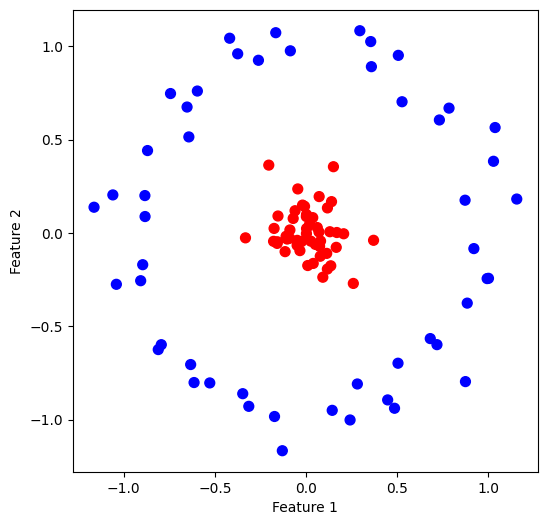

In [5]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(
    n_samples=100,  # total number of points
    factor=0.1,     # scale factor between inner and outer circle
    noise=0.1,      # adds randomness to the circles
    random_state=42 # for reproducibility
)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [7]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6

In [10]:
#  Ofc the accuarcy will be low coz we are applying Straight(linear) Decision Boundary on Non linear datasets

In [16]:
#  Lets Visualise
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\Shubham\AppData\Local\Temp\ipykernel_3220\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


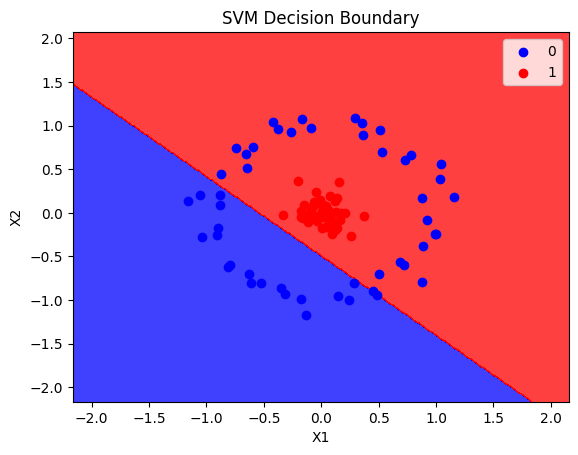

In [15]:
plot_decision_boundary(X, y, classifier)

In [18]:
# Soln : 
# Put the Data in 3D and Multiple w e^-2 , to lift the data points from center

def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

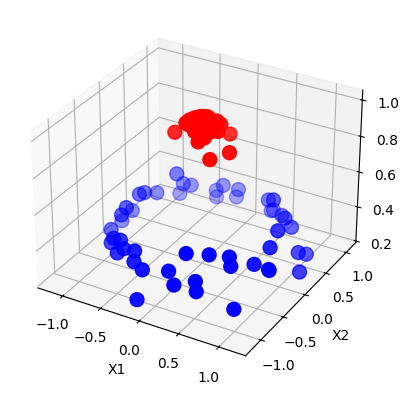

In [19]:
# Visual 3D
plot_3d_plot(X,y)

In [24]:
# Training the 3d dataset
# Using Radial Basis Function (RBF) Kernel
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [25]:
accuracy_score(y_test, y_pred)

1.0

In [22]:
# Acc inc from 60 -> 100 % 

C:\Users\Shubham\AppData\Local\Temp\ipykernel_3220\2622859575.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


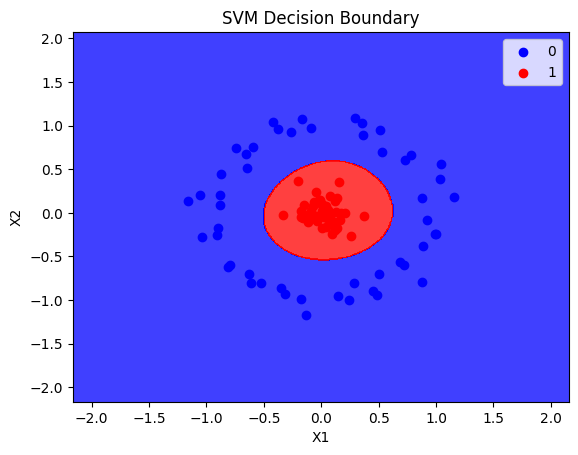

In [23]:
# Visual 3D Decision Boundary  
plot_decision_boundary(X, y, rbf_classifier)

In [26]:
#  Now Using the Polynomial Kernel

poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [27]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\Shubham\AppData\Local\Temp\ipykernel_3220\2622859575.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


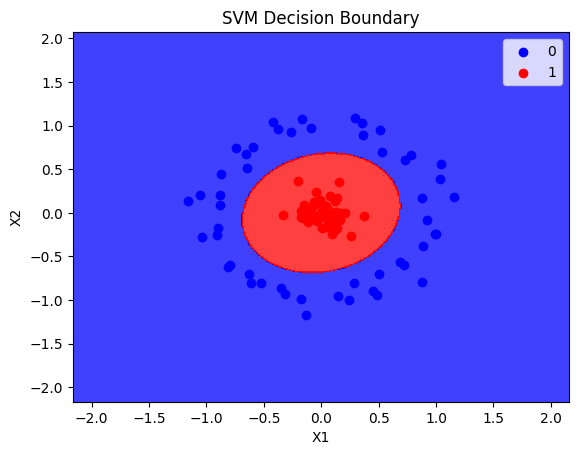

In [28]:
plot_decision_boundary(X, y, poly_classifier)

### What Actually happens with data 

In [30]:
# This is the Original data
X

array([[ 0.01004783, -0.17510486],
       [ 0.14058191,  0.16717858],
       [-0.059743  ,  0.11848299],
       [ 0.71938348, -0.59898403],
       [ 0.87586276, -0.79693694],
       [ 0.28238185, -0.8096356 ],
       [-0.88398798,  0.19969581],
       [-0.04821718, -0.06689042],
       [ 0.35579647,  1.02466875],
       [ 0.92202981, -0.08438964],
       [-0.65247738,  0.67395748],
       [-0.79396809, -0.59912738],
       [ 0.16649451, -0.0776401 ],
       [-0.61403158, -0.80193362],
       [ 0.11817221,  0.13361695],
       [ 1.03859873,  0.56412698],
       [-0.06990555,  0.07712972],
       [-0.15789052, -0.05648558],
       [-0.08545191,  0.97514198],
       [-0.6327045 , -0.70551635],
       [ 0.00349741,  0.02280071],
       [ 0.07868738, -0.12537914],
       [-0.90712258, -0.25646566],
       [ 0.4487963 , -0.89499225],
       [-0.20389193,  0.36282105],
       [-0.41864357,  1.04254495],
       [ 0.24241093, -1.00243527],
       [ 0.11776295, -0.19402706],
       [ 0.35950546,

In [32]:
# After Transfoming the data becomes
np.exp(-(X**2)).sum(1)

array([1.96970264, 1.95286901, 1.98249699, 1.29452791, 0.99421924,
       1.44253415, 1.41865505, 1.99321347, 1.23105048, 1.42025922,
       1.28823872, 1.23079337, 1.96665041, 1.21155387, 1.96843732,
       1.06747033, 1.9891938 , 1.97219322, 1.37911696, 1.27800381,
       1.99946803, 1.97823041, 1.37551068, 1.26644539, 1.83593765,
       1.17649713, 1.30902002, 1.94928093, 1.33150717, 1.96689525,
       1.22569839, 1.32425436, 1.93646636, 1.41937887, 1.86368429,
       1.27831884, 1.96935916, 1.94417647, 1.32795332, 1.26762836,
       1.31334476, 1.36260118, 1.36757226, 1.97162503, 1.26543551,
       1.14849045, 1.99347692, 1.45088662, 1.99729731, 1.28975443,
       1.23981815, 1.2095888 , 1.26257824, 1.38425804, 1.17800665,
       1.97996745, 1.1793786 , 1.9898817 , 1.3505942 , 1.9769267 ,
       1.95794625, 1.99043945, 1.85948091, 1.388388  , 1.98279822,
       1.99198329, 1.35297238, 1.9576969 , 1.9778185 , 1.86957798,
       1.99130015, 1.20277196, 1.97501907, 1.30861869, 1.98914

In [36]:
# Visualise this in 2D
X_new=np.exp(-(X**2))

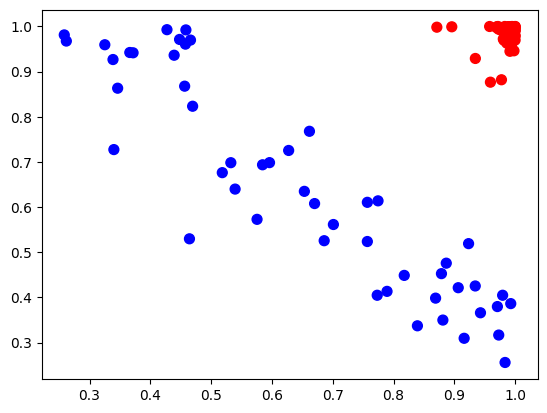

In [37]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')